In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RESULTS_DIR = Path("../results")

In [2]:
rows = []
for f in sorted(RESULTS_DIR.glob("*_models.json")):
    with open(f) as fh:
        entries = json.load(fh)
    # Older files may wrap the list in a dict; handle both shapes.
    if isinstance(entries, dict):
        entries = entries.get("models", [])
    for e in entries:
        rows.append({"notebook": f.stem.split("_")[0], **e})

res = pd.DataFrame(rows)
print(f"{len(res)} entries loaded from {res['notebook'].nunique()} notebooks")
res[["notebook", "model", "notes", "auc", "gini", "ap"]]

10 entries loaded from 2 notebooks


,notebook,model,notes,auc,gini,ap
0,01,Logistic Regression,with calc,0.6324,0.2648,0.0637
1,01,Logistic Regression,without calc,0.6331,0.2663,0.0640
2,01,Random Forest,with calc,0.6345,0.2689,0.0648
3,01,Random Forest,without calc,0.6339,0.2677,0.0651
4,01,XGBoost,with calc,0.6413,0.2825,0.0676
5,01,XGBoost,without calc,0.6423,0.2846,0.0683
6,01,Stacking,with calc,0.6403,0.2807,0.0677
7,01,Stacking,without calc,0.6409,0.2819,0.0682
8,02,Logistic Regression,"hold-out, with calc",0.6286,0.2571,NaN
9,02,LightGBM,"hold-out, with calc",0.6036,0.2072,NaN


### Model Comparison : 

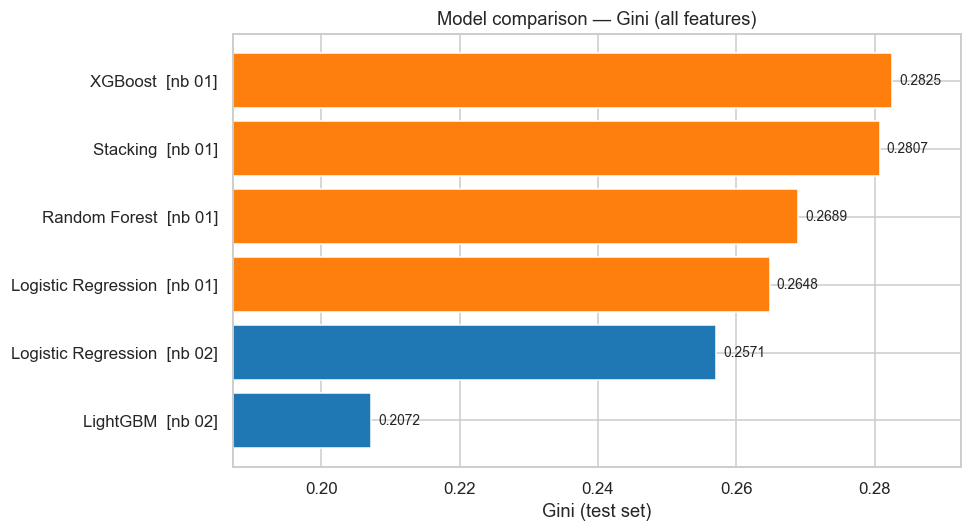

In [6]:
with_calc = ranked[ranked["notes"].str.contains("with calc", na=False)
                   & ~ranked["notes"].str.contains("without", na=False)]

top = with_calc.sort_values("gini")
nb_codes, _ = pd.factorize(top["notebook"])
palette = plt.cm.tab10(np.linspace(0, 1, 10))
colors = [palette[c % 10] for c in nb_codes]

plt.figure(figsize=(9, 0.5 * len(top) + 2))
plt.barh(top["model"] + "  [nb " + top["notebook"] + "]", top["gini"],
         color=colors)
plt.xlabel("Gini (test set)")
plt.xlim(top["gini"].min() - 0.02, top["gini"].max() + 0.01)
plt.title("Model comparison — Gini (all features)")
plt.grid(True, axis="x", zorder=-3)

for i, v in enumerate(top["gini"]):
    plt.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Best Model : 

In [5]:
best = ranked.iloc[0]
print(f"Best model: {best['model']}  (notebook {best['notebook']}, {best['notes']})")
print(f"  AUC  {best['auc']:.4f}")
print(f"  Gini {best['gini']:.4f}")
if pd.notna(best["ap"]):
    print(f"  AP   {best['ap']:.4f}  ({best['ap']/best['base_rate']:.2f}x base rate)")
print("\nParameters:")
for k, v in best["params"].items():
    print(f"  {k}: {v}")

Best model: XGBoost  (notebook 01, without calc)
  AUC  0.6423
  Gini 0.2846
  AP   0.0683  (1.88x base rate)

Parameters:
  subsample: 1.0
  reg_lambda: 1
  reg_alpha: 5
  n_estimators: 1600
  min_child_weight: 100
  max_depth: 5
  learning_rate: 0.01
  colsample_bytree: 0.6
